<a href="https://colab.research.google.com/github/Raldulff/SIR-EnKF/blob/main/SIR_EnKF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Familia SIR


## Modelo SIR Determinista


Sistema de Ecuaciones:

$$s'(t) = -\lambda s(t)i(t)$$$$i'(t) = \lambda s(t)i(t) - \gamma i(t)$$$$r'(t) = \gamma i(t)$$


El modelo asume que la comunidad es homogenea y cerrada (sin nacimientos, muertos ni migraciones).

Las funciones representan a las diferentes fracciones de la comunidad:

*   $s(t):$ Es la parte de la poblacion compuesta por individuos susceptibles en el tiempo t. Aquellos que se pueden enfermar

*   $i(t):$ Es la fraccion de la comunidad compuesta por individuos infectados en el tiempo t. Quienes portan la enfermedad y pueden trasmitirla

*   $r(t):$ Es la fracion de la comunidad compuesta por individuos recuperados en el tiempo t. Quienes se recuperaron de la enfermedad, se asume que se vuelven inmunes   

Debido a la que la comunidad es cerrada, para todo $t\geq 0$

$$s(t) + i(t) + r(t) = 1$$

El cambio de las poblaciones esta dado por 2 tasas constantes



*   $\lambda$ **Tasa de infección o contacto:** Este parametro controla el ritmo al que los susceptibles se infectan
*   $\gamma$ **Tasa de recuperacion :** Es la tasa a la que los individuos infecciosos se recuperan y se vuelven inmunes. Por lo que $\frac{1}{\gamma}$ representa el tiempo esperado del periodo de infeccion de una persona

La relacion entre las 2 constantes es el Numero Basico de Reproduccion $(R_0)$, definido como: $$R_0= \frac{\lambda}{\gamma}$$
Este numero representa la cantidad promedio de nuevas infecciones ue causara un indiviiduo infectado antes de su recuperacion.

Siendo que $R_0=1$ es el punto de división entre 2 escenarios distintos.

Si $R_0\leq 1$, es decir una persona infectada contagia a un numero pequeño de personas, entonces la enfermedad no tiene la fuerza para sostenerse y desaparece al poco tiempo, conocido como un brote menor

Si $R_0 \geq 1 $, es decir si un individuo contagia a más de una persona, el brote tiene la capacidad de multiplicarse e infectar a una gran parte de la comunidad

El modelo SIR determinista presenta limitaciones clave que no lo hacen el más confiable, lo siguiente es una lista de eso:

*    El modelo aunque asumiendo homogeneidad, este no es bueno para modelar poblaciones pequeñas

*    Si el $R_0 > 1$ el modelo asume que  el brote se esparcirá , sin embargo es posible que la enfermedad no se extienda debido al número de infectados iniciales

*    El modelo no toma el cuneta la variabilidad demográfica o ambiental

*    El modelo asume la homogeneidad y

## SEIR
El modelo SEIR es una extension del modelo SIR, el cual divide a la poblacion en 4 grupos de personas $S$ suceptibles, $E$ expuestos, $I$ Infecciosos, $R$ recuperados, y obedecen al siguiente sistema de ecuaciones:

$$\frac{dS}{dt} = b(N-S)-\beta SI$$

$$\frac{dE}{dt} = \beta SI -\sigma E - bE$$

$$\frac{dI}{dt} = \sigma E - bI - \gamma I$$

$$\frac{dR}{dt} =\gamma I - bR$$

En donde:
* $b:=$ Tasa de natalidad y mortalidad, representa que tan rapido nacen y mueren las personas pro causas ajenas a la enfermedad
* $\beta:=$ Tasa de transmisión, representa que tan efectivo es que un contacto resulte en una infeccion
* $\sigma:=$ Tasa de progresión, velocidad en la que un individuo pas ade estar expuesto a estar infeccioso, el inverso puede verse como el tiempo de incubacion de la enfermedad
* $\gamma:=$ Tasa de recuperacion, es la veloidad a la que los infecciosos se curan.

La suma de $S(t)+E(t)+I(t)+R(t)=N$ da como resultado la poblacion total.

La primera ecuacion representa a los susceptibles, es decir,  los sujetos que nacen, menos los susceptibles que mueren por cosas ajenas a la infeccion, menos las personas que se contagian por estar en contacto con las personas infectadas.

La segunda ecuacion, representa a las personas expuestas, compuesta por aquellos que se contagiaron, menos las que ya terminaron el periodo de incubacion y se vuelven contagiosas, menos las que mueren por causas naturales

La tercera ecuacion, los infectados, compuesta por las personas que terminaron su periodo de incubacion, menos las que murieron de forma ajena a la infeccion, menos las personas que se recuperan de la enfermmedad.

El numero basico de Reproduccion $(R_0)$

definido como:

$$R_0=\left(\frac{\beta N}{\gamma + b}\right) \left( \frac{\sigma}{\sigma + b}\right)$$

Explica a cuantas personas contagiara un "paciente cero"
* La probabilidad de sobrevivir a la incubacion $\left( \frac{\sigma}{\sigma + b}\right)$, es la probabilidad de que un individuo llegue a la fase infeccioa en lugar de morir.
* El potencial de contagio $\left(\frac{\beta N}{\gamma + b}\right)$, si el paciente se vuelve infeccioso, esto nos dira a cuantas perosnas va a contagiar.


## SEIRD

El modelo SEIRD divide a la poblacion total $N$ en 5 partes: Susceptibles ($S$), Expuestos ($E$), Infectados ($I$), Recuperados ($R$), y Muestos/Fallecidos ($D$), obedeciendo el siguiente sistema de ecuaciones diferenciales:

$$\frac{dS}{dt} = -\frac{\beta SI}{N} $$

$$\frac{dE}{dt} = \frac{\beta SI}{N}- \alpha E $$

$$\frac{dI}{dt} = \alpha E - \gamma I - \delta I$$

$$\frac{dR}{dt} = \gamma I $$

$$\frac{dD}{dt} = \delta I $$

En donde:
* $\beta$ (Tasa de transmision): la probabilidad de que el contacto entre una persona susceptible y una infectada resulte en exposicion al virus
* $\alpha$ (Tasa de progresion/conversion): representa la velocidad a la que los individuos expuestos desarrollan la enfermedad y pasan a ser infectados. El inverso es el periodo de incubacion
* $\gamma$ (Tasa de recuperacion): es la vvelocidad a la que los infectados se recuperan
* $\delta$ (Tasa de mortalidad): tasa a la que los individuos infectados fallecen

Ecuaciones:

$\frac{dS}{dt}$, los susceptibles disminuyen al entrar en contacto con los infectados

$\frac{dE}{dt}$, los expuestos crecen an la proporcion en la que los susceptibles se contagian, pero disminuyen a una tasa $\alpha$ a medida que la enfermedad se desarrolla y se vuelven infectados

$\frac{dI}{dt}$, Los infectados aumentan gracias a los que llegan de la etapa de exposicion , mientras decrece por las personas que se recuperan y las que fallecen

$\frac{dR}{dt}$, los recuperados incrementan por la poblacion que sale de la infeccion a una tasa $\gamma$

$\frac{dD}{dt}$, las muertes  acumuladas por las personas que no pudieron recuperarse durante el contagio

### Numero de Reproduccion Basico ($R_0$)

Al igual que en los modelos SIR y SEIR, $R_0$ nos indicara si una epodemia se extingira o se propagara
Para el modelo SEIRD, $R_0$ se define como:
$$R_0=\left(\frac{\beta}{\gamma + \delta} \right) $$
PUes cada individuo genera contagios durante el tiempo que pasa en $I$, y se acaba cuando sale, ya sea por recuperacion o muerte.

### Ventajas

Al incluir la curva de fallecidos nos da una mayor informacion para la toma de decisiones y la gravedad de la cepa






# Codigo


In [1]:
# Paqueterias necesarias
!pip install dapper
import numpy as np
import numpy.random as rnd
import numpy.linalg as nla
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from dapper.mods.integration import rk4


INFO: pip is looking at multiple versions of pathos to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.2/330.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
  Attempting uninstall: notebook
    Found existing installation: notebook 6.5.7
    Uninstalling notebook-6.5.7:
      Successfully uninstalled notebook-6.5.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

## Funciones globales

In [3]:
# 1. Función Global para Observaciones (Soporta 1 o múltiples variables)
def Obs(E, t, obs_idx):
    # Aseguramos que obs_idx sea una lista para que el slicing sea consistente
    if isinstance(obs_idx, int):
        obs_idx = [obs_idx]

    # Extraemos las filas correspondientes dependiendo de si es un vector o matriz
    if E.ndim == 1:
        return E[obs_idx]
    else:
        return E[obs_idx, :]


# 2. Fábrica de Funciones Global para la Dinámica de cualquier modelo
def create_Dyn(dxdt_func):
    """
    Recibe la función de las ecuaciones diferenciales (ej. dxdt_sir, dxdt_SEIRD)
    y devuelve una función Dyn compatible con tu ciclo EnKF.
    """
    def general_Dyn(E, t0, dt):
        def step(x0):
            # Usamos rk4 pasándole la función dinámica correspondiente
            return rk4(lambda x, t: dxdt_func(x), x0, t0, dt)

        if E.ndim == 1:
            return step(E)
        else:
            for n in range(E.shape[1]):
                E[:, n] = step(E[:, n])
            return E

    return general_Dyn

In [17]:
def EnKF(N, xa, matrices, Dyn_f, obs_idx,
         sim_data, dt=0.1, dko=20, nTime=1020, Obs_f=Obs):
    """
    Filtro de Kalman por Ensambles (EnKF) generalizado.
    """
    #desempaquetamos las observaciones
    obsrvs = sim_data[1]

    # 1. Desempaquetar matrices
    Pa12, Q12, R12 = matrices

    # 2. Deducir dimensiones automáticamente
    xDim = xa.shape[0]
    p = R12.shape[0]

    # calculo de la matriz R
    R = R12 @ R12.T

    # arreglos para guardar las estadisticas
    ens_means = np.zeros((nTime + 1, xDim))
    ens_vrncs = np.zeros((nTime + 1, xDim))

    # Inicializacion del ensamble
    E = xa[:, None] + Pa12 @ rnd.randn(xDim, N)
    E = np.clip(E, 0, 1)

    # Guardamos el instante 0 (opcional, pero recomendado para gráficas completas)
    ens_means[0] = np.mean(E, axis=1)
    ens_vrncs[0] = np.var(E, axis=1, ddof=1)

    # ciclo principal
    for k in tqdm(range(1, nTime + 1)):
        t = k * dt

        # pronostico
        E = Dyn_f(E, t - dt, dt)
        E += Q12 @ rnd.randn(xDim, N)

        # analisis
        if k % dko == 0:
            y = obsrvs[[k // dko - 1]].T
            Eo = Obs_f(E, t, obs_idx)

            # momentos del ensamble
            Y = Eo - Eo.mean(keepdims=True)
            X = E - E.mean(keepdims=True)
            PH = X @ Y.T / (N - 1)
            HPH = Y @ Y.T / (N - 1)

            # ganancia de kalman y perturbaciones
            KG = nla.solve(HPH + R, PH.T).T
            Perturbs = R12 @ rnd.randn(p, N)

            # actualizacion
            E += KG @ (y - Eo - Perturbs)
            E = np.clip(E, 0, 1.0) # Mantener poblaciones entre 0 y 1

        ens_means[k] = np.mean(E, axis=1)
        ens_vrncs[k] = np.var(E, axis=1, ddof=1)

    return ens_means, ens_vrncs

In [9]:
def syn_data(xa, matrices, Dyn_f, obs_idx,
             dt=0.1, dko=20, nTime=1020, Obs_f=Obs):
    """
    Genera la realidad (truths) y las observaciones sintéticas (obsrvs).
    Recibe un agrupamiento 'matrices' que contiene (Pa12, Q12, R12).
    """
    # Desempaquetar las matrices
    Pa12, Q12, R12 = matrices

    # 1. Deducir dimensiones automáticamente
    xDim = xa.shape[0]
    p = R12.shape[0]

    # Calculamos la cantidad exacta de observaciones
    num_obs = nTime // dko

    # 2. Inicializar arreglos
    truths = np.zeros((nTime + 1, xDim))
    obsrvs = np.zeros((num_obs, p))

    # 3. Condición inicial (perturbada)
    truths[0] = xa + Pa12 @ rnd.randn(xDim)
    truths[0] = np.clip(truths[0], 0, 1) # Mantener proporciones entre 0 y 1

    # 4. Ciclo de simulación principal
    for k in range(1, nTime + 1):
        # Evolución temporal (Mundo Real) + Error del modelo
        truths[k] = Dyn_f(truths[k-1], (k-1)*dt, dt)
        truths[k] += Q12 @ rnd.randn(xDim)

        # Extraer observación si el paso de tiempo coincide
        if k % dko == 0:
            obs_k = (k // dko) - 1

            observacion_limpia = Obs_f(truths[k], np.nan, obs_idx)
            ruido_sensor = R12 @ rnd.randn(p)

            obsrvs[obs_k] = observacion_limpia + ruido_sensor
            obsrvs[obs_k] = np.maximum(obsrvs[obs_k], 0)

    return truths, obsrvs

In [10]:
# Funcion que grafica

def plot_enkf(syn_data_out, enkf_out ,obs_idx ,
              labels=None,dt= 0.1, dko=20 ,title="Resultados EnKF"):
  #desempaquetar la verdad sintetica
  means, vars= enkf_out
  truths, obrsvs = syn_data_out

  # Asegurar que obs_idx sea una lista
  if isinstance(obs_idx, int):
    obs_idx = [obs_idx]

  nTime = truths.shape[0]-1
  xDim = truths.shape[1]
  ko = obrsvs.shape[0]-1

  # ejes
  t_full = dt * np.arange(nTime + 1)
  t_obs = (dt * dko) * np.arange(1, ko + 2)

  # paleta de colores para modelos grandes
  cmap =plt.get_cmap('tab10')

  # figura
  fig, axs = plt.subplots(nrows=xDim, sharex=True, figsize=(8, 2.5 * xDim))

  if xDim == 1:
    axs = [axs]

  # graficas
  for i in range(xDim):
    c=cmap(i % 10)

    # grafica de las verdades
    axs[i].plot(t_full, truths[:, i], 'k-', label="Realidad")

    #grafica media del EnKF
    axs[i].plot(t_full, means[:, i], color = c, label="Estimación EnKF")

    # grafica incertidumbre
    std_dev = np.sqrt(vars[:, i])
    axs[i].fill_between(t_full,
                        means[:, i] - std_dev,
                        means[:, i] + std_dev,
                        color=c, alpha=0.2, label= "Incertidumbre" )

    # grafica de observaciones
    if i in obs_idx:
      obs_col = obs_idx.index(i)
      axs[i].plot(t_obs, obrsvs[:, obs_col], 'k*', label="Observaciones")

    axs[i].set_ylabel(labels[i])
    axs[i].grid(True, linestyle='--', alpha=0.6)
    if i == 0:
      axs[i].set_title(title)
      axs[i].legend()

  # grafica
  plt.xlabel("Tiempo")
  plt.tight_layout()
  plt.show()

In [11]:
#grafica de la Raiz del Error Cuadrado Medio (RMSE)
def plot_rmse(syn_data_out, enkf_out,
              dt=0.1, dko=20, title="RMSE EnKF"):

  #desempaquetar solo las salidas de las funciones necesarias
  truths, _= syn_data_out
  means, _= enkf_out

  nTime = truths.shape[0]-1
  t_full = dt * np.arange(nTime + 1)

  # calculo del rmse en cada innstante de tiempo
  rmse_t = np.sqrt(np.mean((truths - means)**2, axis=1))

  # configuracion de la grfica
  plt.figure(figsize=(10, 4))

  # linea principal del error
  plt.plot(t_full, rmse_t, 'r-', label="RMSE EnKF")

  # marcas en los momentos de asimilacion
  if dko is not None:
    # tiempo donde ocurrio la observacion
    t_obs = (dko * dt) * np.arange(1, (nTime // dko) + 1)

    for i, to in enumerate(t_obs):
      label = 'Asimilacion de Datos' if i == 0 else None
      plt.axvline(x=to, color='green', linestyle='--', label=label)

  plt.xlabel("Tiempo")
  plt.ylabel("RMSE")
  plt.title(title)
  plt.grid(True, linestyle=':', alpha=0.6)
  plt.legend()

  plt.ylim(bottom=0)
  plt.tight_layout()
  plt.show()

  rmse_global = np.mean(rmse_t)
  print(f"RMSE Global: {rmse_global:.4f}")

  return rmse_global

## modelos de la familia SIR

In [12]:
#modelo SIR
def dxdt_sir(x, beta=0.3, gamma=0.1):
    S, I, R = x
    d = np.zeros(3)
    d[0] = -beta * S * I
    d[1] = beta * S * I - gamma * I
    d[2] = gamma * I
    return d

#modelo SEIR
def dxdt_SEIR(x, beta=0.5,sigma=0.2, gamma=0.1, b=0.01, N_pop=1.0):
    S, E, I, R = x
    d = np.zeros(4)
    # dS/dt = b(N-S) - beta*S*I
    d[0] = b * (N_pop - S) - beta * S * I
    # dE/dt = beta*S*I - sigma*E - b*E
    d[1] = beta * S * I - sigma * E - b * E
    # dI/dt = sigma*E - b*I - gamma*I
    d[2] = sigma * E - b * I - gamma * I
    # dR/dt = gamma*I - b*R
    d[3] = gamma * I - b * R
    return d




## EnKF en accion

In [14]:
# Asimilacion para los infectados en el modleo SEIR

xDim_seir = 4
N = 500
labels = [ 'Susceptibles', 'Expuestos', 'Infectados', 'Recuperados']

#condiciones iniciales y covarianza
xa_seir = np.array([0.98,0.01,0.01,0.0])
Pa12_seir = np.diag([0.05,0.02,0.02,0.0])
Q12_seir = np.zeros((xDim_seir,xDim_seir))

#variables especificas para medir infectados
obs_idx_I= 2
R12_I = np.array([[0.02]])
matrices_I = (Pa12_seir, Q12_seir, R12_I)

#dinamica global para SEIR
Dyn_SEIR = create_Dyn(dxdt_SEIR)

#observaciones sinteticas
syn_data_I = syn_data(xa_seir, matrices_I, Dyn_SEIR, obs_idx_I)


In [18]:
# asimilacion con EnKF
enkf_out_I = EnKF(N, xa_seir, matrices_I,
                  Dyn_SEIR, obs_idx_I,
                  syn_data_I)

  0%|          | 0/1020 [00:00<?, ?it/s]

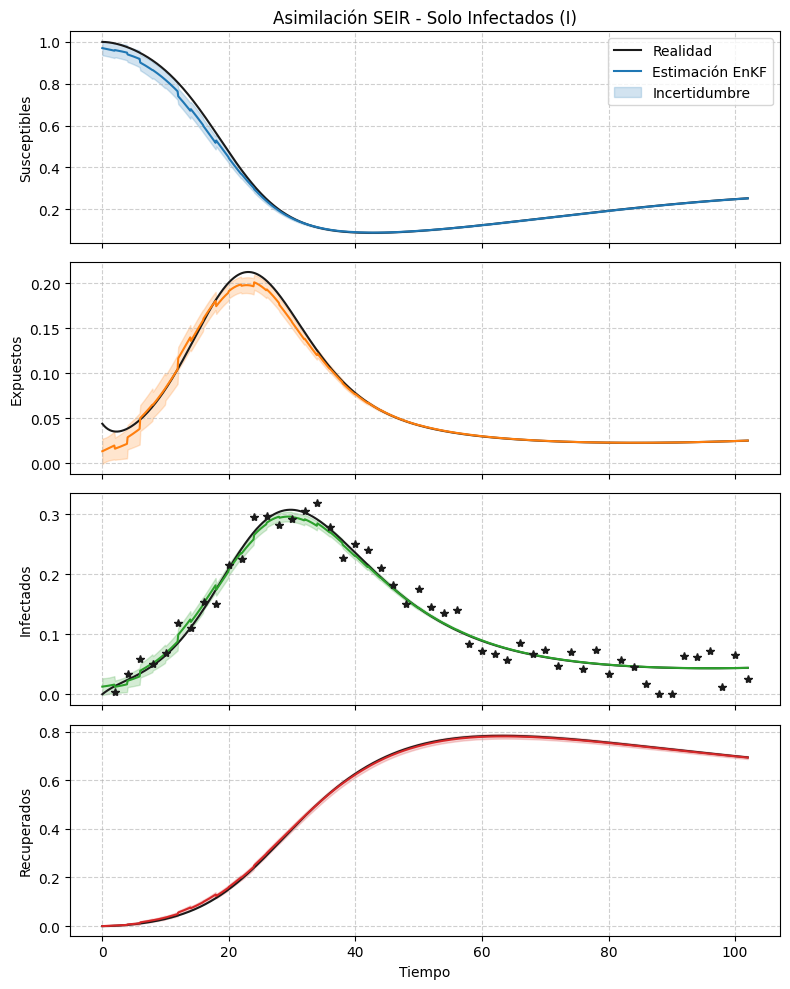

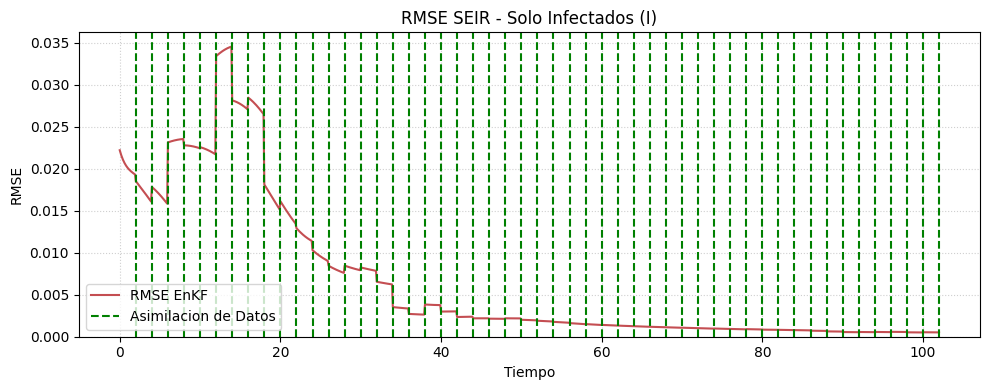

RMSE Global: 0.0067


np.float64(0.006746535124733788)

In [19]:
# Gráficas
plot_enkf(syn_data_I, enkf_out_I, obs_idx_I,
          labels=labels, title="Asimilación SEIR - Solo Infectados (I)")
plot_rmse(syn_data_I, enkf_out_I, title="RMSE SEIR - Solo Infectados (I)")

In [24]:
# Asimilacion de datos sobre I y R en el modelo SEIR

obs_idx_IR =[2,3]
R12_IR = np.diag([0.02,0.01])
matrices_IR = (Pa12_seir, Q12_seir, R12_IR)

#generacion de datos sinteticos
syn_data_IR = syn_data(xa_seir, matrices_IR, Dyn_SEIR,
                       obs_idx_IR)


In [25]:
# Asimilacion con EnKF
enkf_out_IR = EnKF(N, xa_seir, matrices_IR, Dyn_SEIR,
                   obs_idx_IR, syn_data_IR)

  0%|          | 0/1020 [00:00<?, ?it/s]

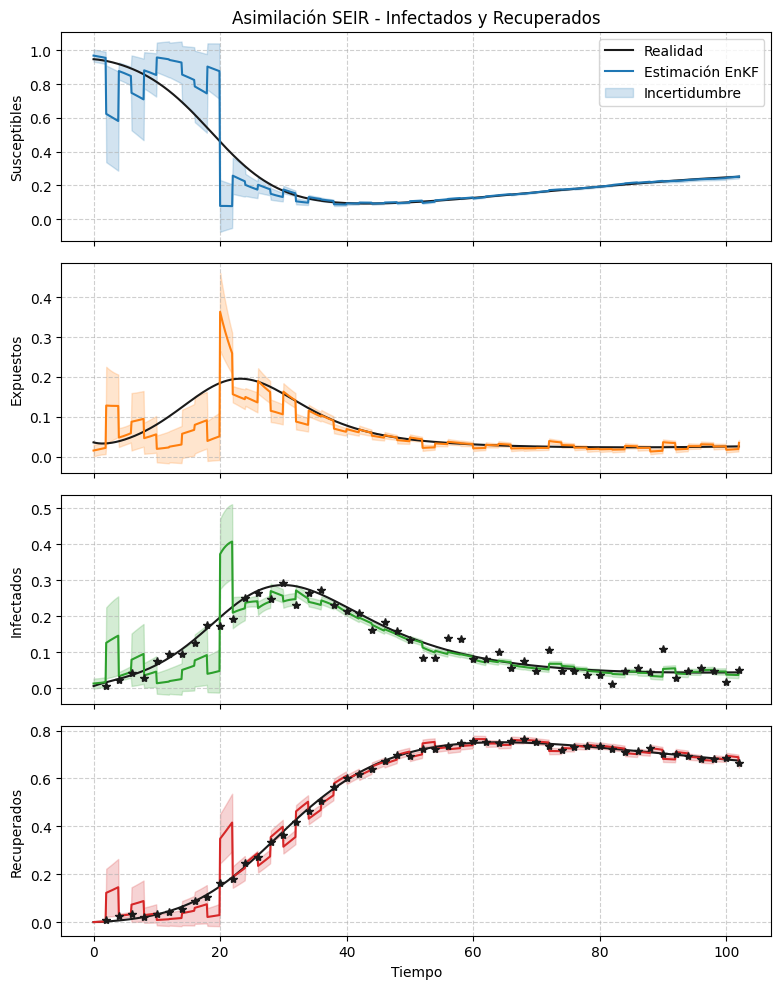

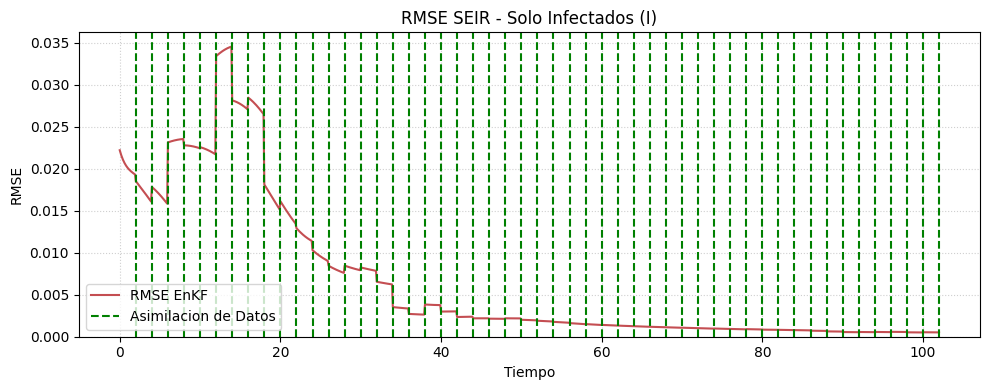

RMSE Global: 0.0067


np.float64(0.006746535124733788)

In [27]:
#graficas
plot_enkf(syn_data_IR, enkf_out_IR, obs_idx_IR,
          labels=labels, title="Asimilación SEIR - Infectados y Recuperados")
plot_rmse(syn_data_I, enkf_out_I, title="RMSE SEIR - Solo Infectados (I)")

In [28]:
# Asimilacion de dato usanod los recuperados

obs_idx_R = 3
R12_R = np.diag([[0.01]])
matrices_R = (Pa12_seir, Q12_seir, R12_R)

#datos simulados
syn_data_R = syn_data(xa_seir, matrices_R, Dyn_SEIR,
                       obs_idx_R)


In [29]:
#Asimilacion de dato sobre R
enkf_out_R = EnKF(N, xa_seir, matrices_R, Dyn_SEIR,
                  obs_idx_R, syn_data_R)

  0%|          | 0/1020 [00:00<?, ?it/s]

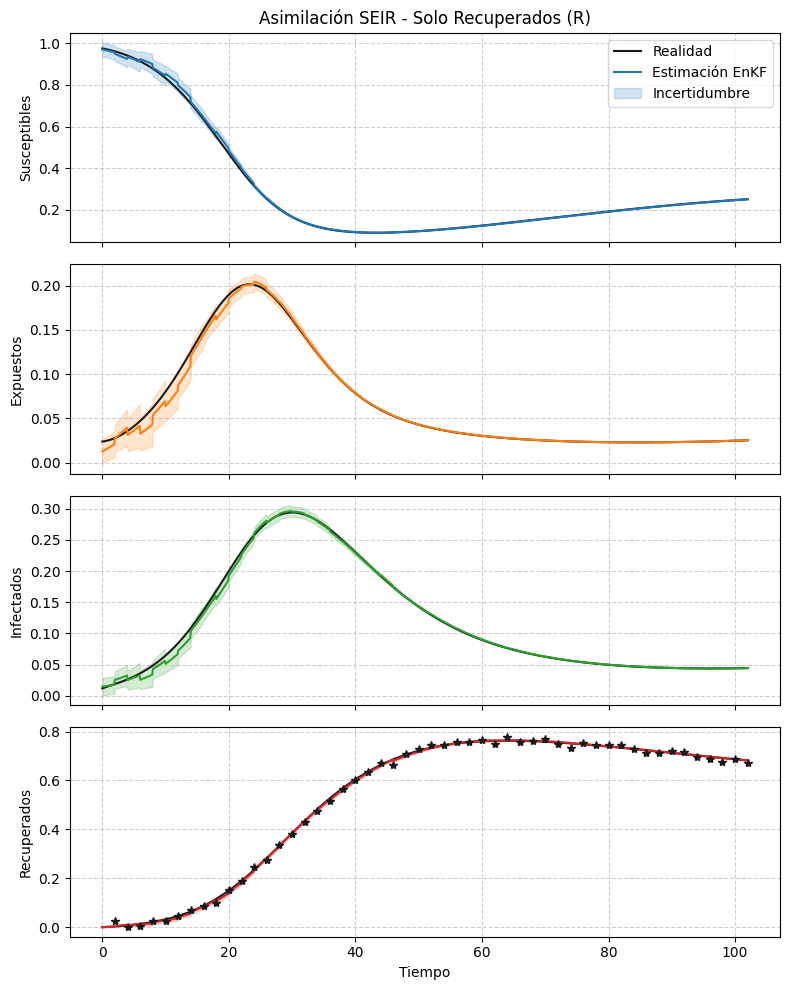

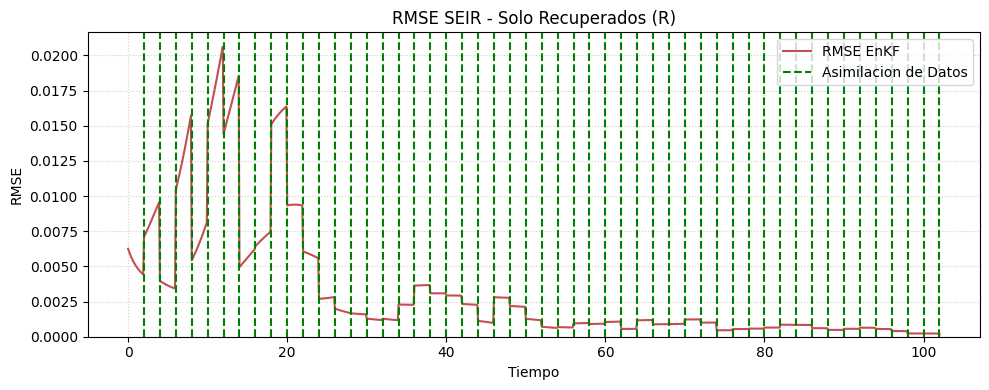

RMSE Global: 0.0032


np.float64(0.003181550223780527)

In [30]:
#  Gráficas
plot_enkf(syn_data_R, enkf_out_R, obs_idx_R,
          labels=labels, title="Asimilación SEIR - Solo Recuperados (R)")
plot_rmse(syn_data_R, enkf_out_R, title="RMSE SEIR - Solo Recuperados (R)")